In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [53]:
st = pd.read_csv('./data/pre_processed.csv', parse_dates=['last_event_di', 'start_time_di'])

In [54]:
st.columns

Index(['course_id', 'userid_di', 'registered', 'viewed', 'explored',
       'certified', 'final_cc_cname_di', 'loe_di', 'gender', 'grade',
       'start_time_di', 'last_event_di', 'nevents', 'ndays_act', 'nplay_video',
       'nchapters', 'nforum_posts', 'age', 'age_segment', 'step',
       'nchapters_flag', 'nevents_flag', 'ndays_act_flag', 'nplay_video_flag',
       'last_event_di_flag', 'age_flag', 'grade_flag', 'duration'],
      dtype='str')

<Axes: >

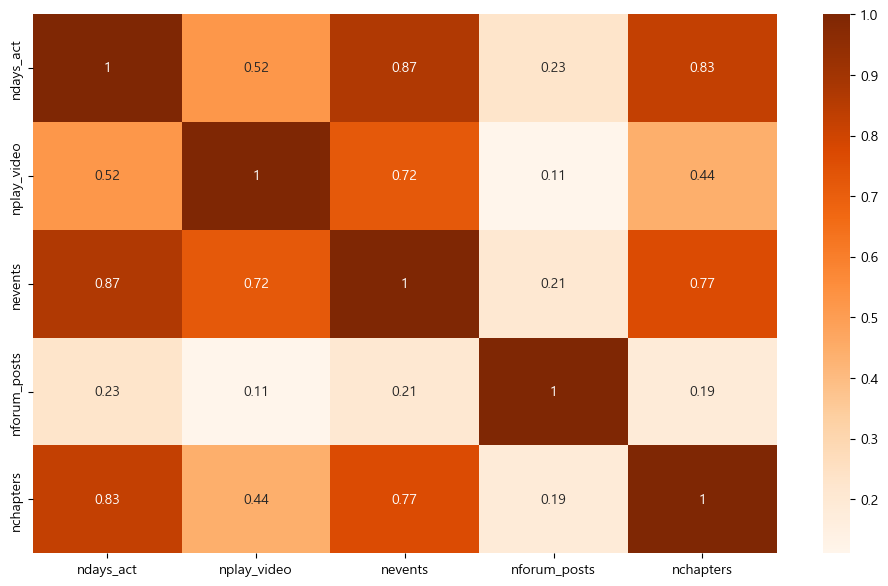

In [55]:
# 사용자 행동지표 별 상관관계 : 다중공선성 확인을 위한 확인과정
st_corr = st[['ndays_act', 'nplay_video', 'nevents', 'nforum_posts','nchapters']].corr()
plt.figure(figsize=(12,7))
sns.heatmap(st_corr, cmap='Oranges', annot=True)

In [56]:
# 다중공선성으로 인해 nevents, nchapters 제거 후 수료여부별 효과크기를 계산을 진행

# nplay_video부터 시작

# 먼저 그룹을 나눔
np_T = st.loc[
    (st['certified']==1)
    , 'nplay_video'
] # 수료를 한 그룹의 nplay_video

np_F = st.loc[
    (st['certified']==0)
    , 'nplay_video'
] # 수료를 못한 그룹의 nplay_video

print(np_T.shape)
print(np_F.shape)


(13426,)
(310492,)


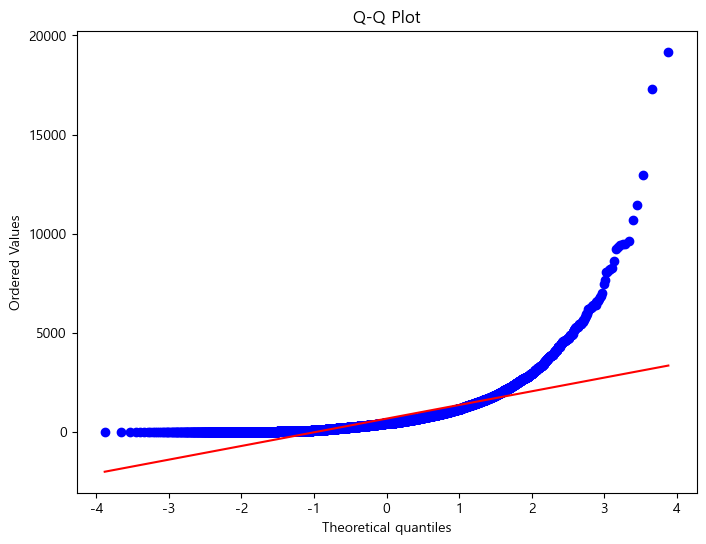

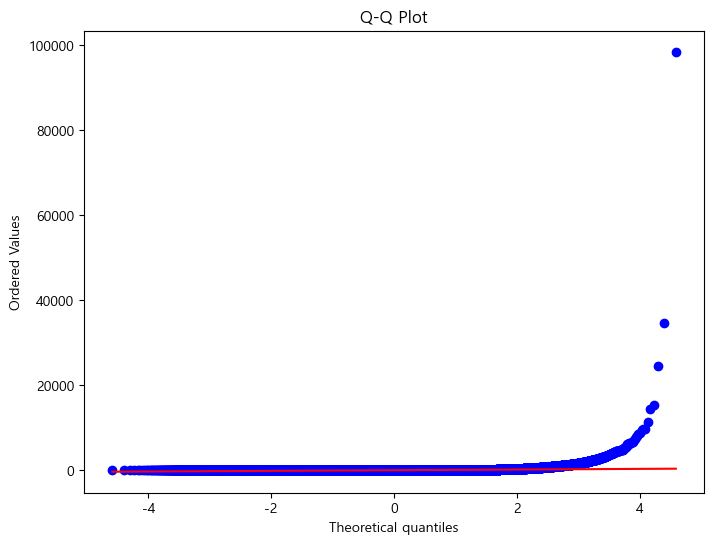

In [57]:
# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(np_T, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(np_F, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

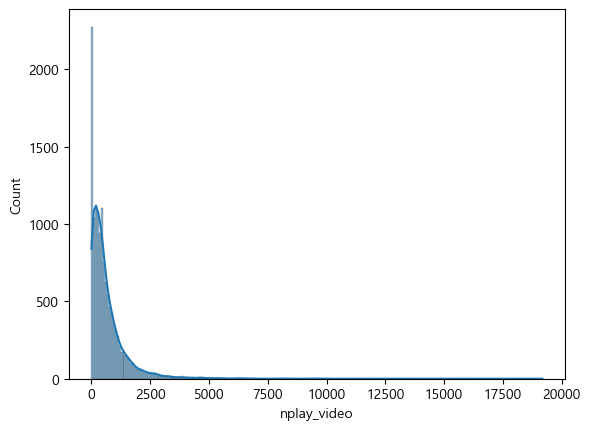

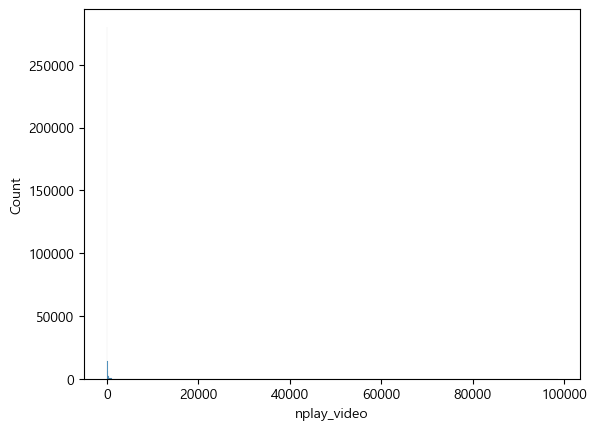

In [58]:
# 히스토그램 그리기
sns.histplot(np_T, kde=True)
plt.show()

sns.histplot(np_F, kde=False)
plt.show()

In [59]:
# 정규성 검정 : 표본 수 차이가 커서 당연히 분산에 차이가 크겠지만, 그래도 과정상 진행
def ks_test(group):
    sample_mean = np.mean(group)
    s = np.std(group, ddof=1)

    statsa, ps = stats.kstest(group,'norm', args=(sample_mean, s))
    return ps

p_np_T = ks_test(np_T)
p_np_F = ks_test(np_F)

print(f'{p_np_T:5f}') # 0.000000 # 정규성 기각
print(f'{p_np_F:5f}') # 0.000000 # 정규성 기각


0.000000
0.000000


In [60]:
# 통계검정 (비모수 검정인 mannwhitneyU검정 수행)

stat_U, p_U = stats.mannwhitneyu(np_T, np_F, alternative='two-sided')
print(stat_U, p_U) # 당연히 p < 0.05

3873276294.0 0.0


In [61]:
def rbc(x, y, stat):
    nx = len(x)
    ny = len(y)
    return ((2 * stat) / (nx * ny))-1

rbc_np = rbc(np_T, np_F, stat_U) 
print(rbc_np) # 0.8582811254676435

0.8582811254676435


In [62]:
# ndays_act 효과크기 계산 시작

# 그룹 분리
na_T = st.loc[
    (st['certified']==1)
    , 'ndays_act'
] # 수료를 한 그룹의 nplay_video

na_F = st.loc[
    (st['certified']==0)
    , 'nplay_video'
] # 수료를 못한 그룹의 nplay_video

print(na_T.shape)
print(na_F.shape)


(13426,)
(310492,)


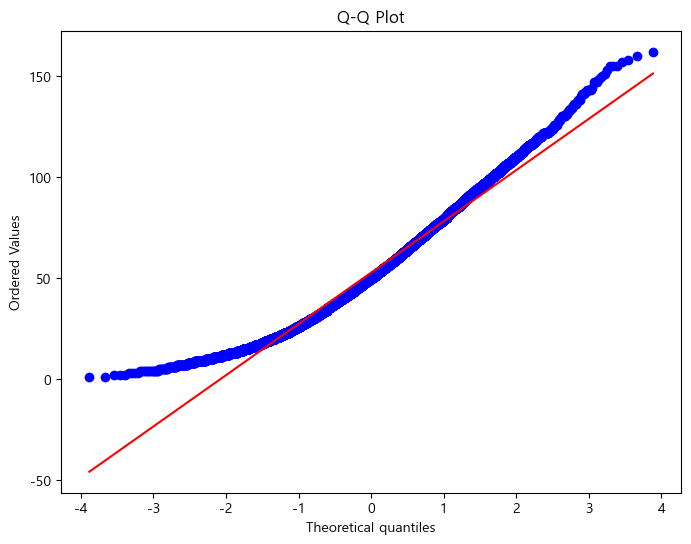

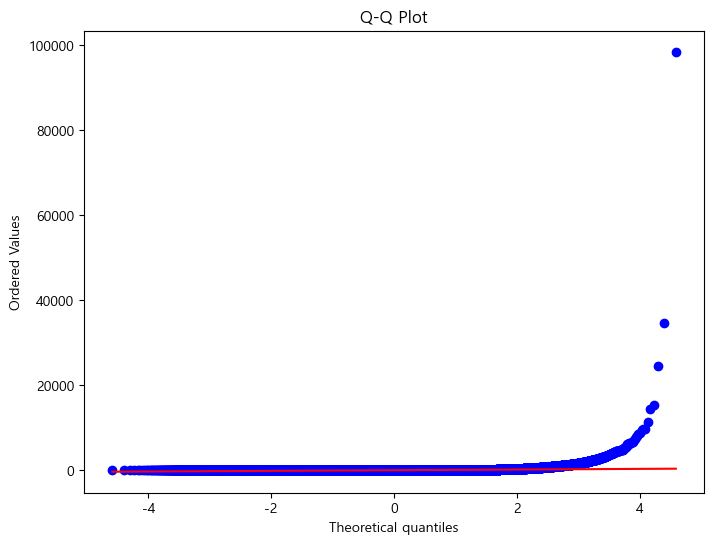

In [63]:
# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(na_T, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(na_F, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

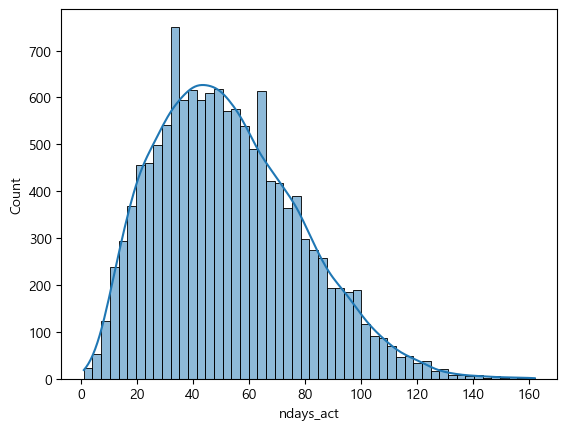

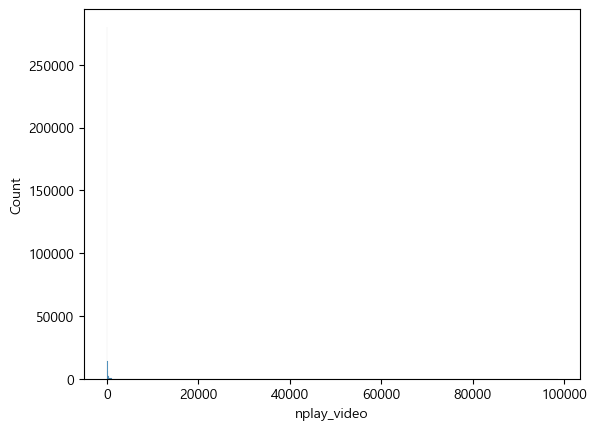

In [64]:
# 히스토그램 그리기
sns.histplot(na_T, kde=True)
plt.show()

sns.histplot(na_F, kde=False)
plt.show()

In [65]:
# 정규성 검정 : 표본 수 차이가 커서 당연히 분산에 차이가 크겠지만, 그래도 과정상 진행
def ks_test(group):
    sample_mean = np.mean(group)
    s = np.std(group, ddof=1)

    statsa, ps = stats.kstest(group,'norm', args=(sample_mean, s))
    return ps

p_na_T = ks_test(na_T)
p_na_F = ks_test(na_F)

print(f'{p_na_T:5f}') # 0.000000 # 정규성 기각
print(f'{p_na_F:5f}') # 0.000000 # 정규성 기각


0.000000
0.000000


In [66]:
# 통계검정 (비모수 검정인 mannwhitneyU검정 수행)

stat_U, p_U = stats.mannwhitneyu(na_T, na_F, alternative='two-sided')
print(stat_U, p_U) # 당연히 p < 0.05

3482938060.5 0.0


In [67]:
def rbc(x, y, stat):
    nx = len(x)
    ny = len(y)
    return ((2 * stat) / (nx * ny))-1

rbc_na = rbc(na_T, na_F, stat_U) 
print(rbc_na) # 0.6710086158909145

0.6710086158909145


In [68]:
# nforum_posts 통계검정 시작

# 그룹 분리
nf_T = st.loc[
    (st['certified']==1)
    , 'nforum_posts'
] # 수료를 한 그룹의 nplay_video

nf_F = st.loc[
    (st['certified']==0)
    , 'nforum_posts'
] # 수료를 못한 그룹의 nplay_video

print(nf_T.shape)
print(nf_F.shape)


(13426,)
(310492,)


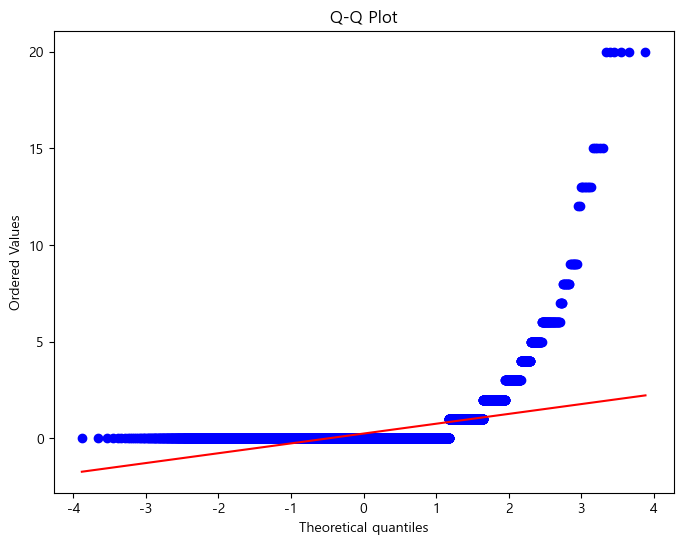

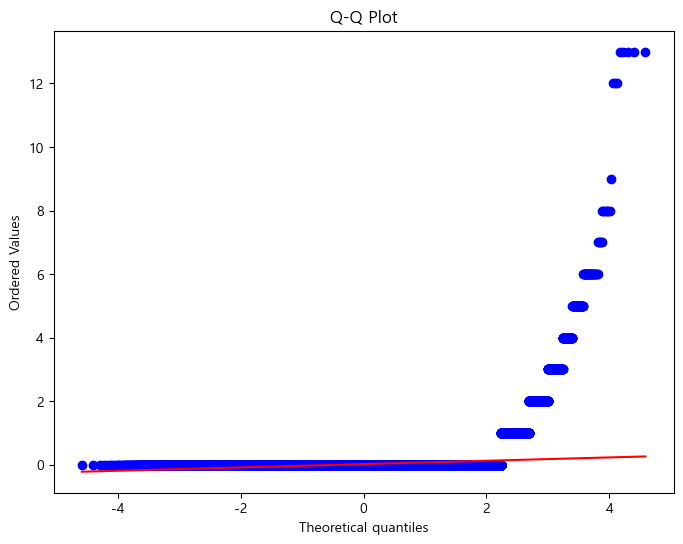

In [69]:
# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(nf_T, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(nf_F, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

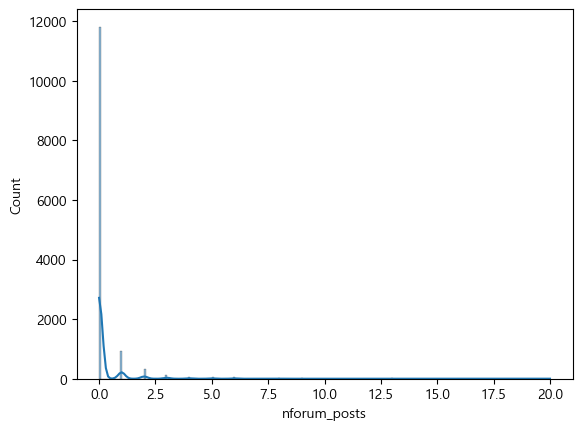

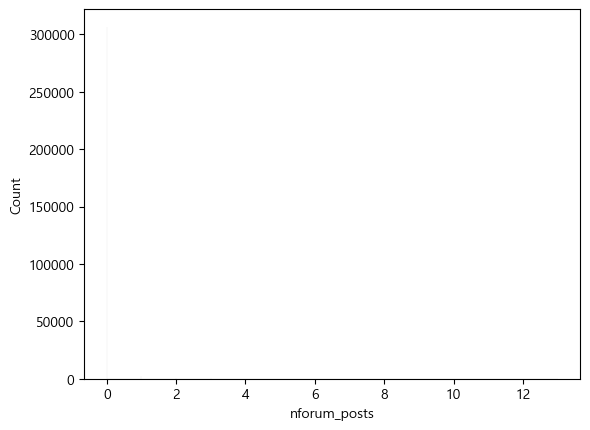

In [70]:
# 히스토그램 그리기
sns.histplot(nf_T, kde=True)
plt.show()

sns.histplot(nf_F, kde=False)
plt.show()

In [71]:
# 정규성 검정 : 표본 수 차이가 커서 당연히 분산에 차이가 크겠지만, 그래도 과정상 진행
def ks_test(group):
    sample_mean = np.mean(group)
    s = np.std(group, ddof=1)

    statsa, ps = stats.kstest(group,'norm', args=(sample_mean, s))
    return ps

p_nf_T = ks_test(nf_T)
p_nf_F = ks_test(nf_F)

print(f'{p_nf_T:5f}') # 0.000000 # 정규성 기각
print(f'{p_nf_F:5f}') # 0.000000 # 정규성 기각


0.000000
0.000000


In [72]:
# 통계검정 (비모수 검정인 mannwhitneyU검정 수행)

stat_U, p_U = stats.mannwhitneyu(nf_T, nf_F, alternative='two-sided')
print(stat_U, p_U) # 당연히 p < 0.05

2308740828.5 0.0


In [73]:
def rbc(x, y, stat):
    nx = len(x)
    ny = len(y)
    return ((2 * stat) / (nx * ny))-1

rbc_nf = rbc(nf_T, nf_F, stat_U)
print(rbc_nf) # 0.10766420455056736

0.10766420455056736


In [76]:
effect_sizes = {
    'nplay_video': rbc_np,
    'ndays_act' : rbc_na,
    'nforum_posts': rbc_nf
}

total = sum(abs(v) for v in effect_sizes.values())

weights ={k: abs(v)/total for k, v in effect_sizes.items()}
weights

{'nplay_video': np.float64(0.5243159880047661),
 'ndays_act': np.float64(0.40991294689005575),
 'nforum_posts': np.float64(0.06577106510517815)}